# Distributional DQN
이 튜토리얼은 **Distributional DQN (C51)**을 구현하는 방법을 안내한다.

**Distributional DQN (C51)**은 기대 보상(Q-Value, 평균값) 하나만을 예측하는 기존 DQN과 달리, **보상의 분포(Distribution)** 자체를 학습한다. 이를 통해 에이전트는 보상의 평균뿐만 아니라 분산(불확실성)까지 파악하여 더 안정적인 학습이 가능하다. 이 알고리즘은 2017년 DeepMind가 발표한 논문 "A Distributional Perspective on Reinforcement Learning"에서 제안되었다.

이 튜토리얼에서는 최신 라이브러리 호환성 및 실행 안정성을 위해 `gymnasium`과 `torch` 최신 버전을 기준으로 작성되었다. 환경은 `LunarLander-v2`를 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [2]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [3]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Distributional Network 생성 (Create the Distributional Network)

기존 DQN은 상태를 입력받아 각 행동의 스칼라 Q값을 출력했다. 하지만 C51은 각 행동마다 **N개의 원자(Atom)**로 이루어진 확률 분포를 출력한다.

* 입력: 상태 (State)
* 출력: 행동 수(Actions)  원자 수(Atoms) 크기의 텐서
* 활성화 함수: 확률 분포이므로 `Softmax`를 사용한다. (Log-Likelihood 계산을 위해 `LogSoftmax` 사용)

In [4]:
class DistributionalDQN(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions, n_atoms):
        """
        Distributional DQN 네트워크 초기화
        :param n_atoms: 분포를 표현할 지지점(Support)의 개수 (보통 51개 사용 -> C51)
        """
        super().__init__()
        self.n_actions = n_actions
        self.n_atoms = n_atoms

        # 특징 추출 레이어
        self.feature_layer = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        # 출력 레이어: (행동 수 * 원자 수) 크기로 출력
        self.fc_out = nn.Linear(hidden_size, n_actions * n_atoms)

    def forward(self, x):
        batch_size = x.size(0)
        features = self.feature_layer(x.float())
        out = self.fc_out(features)

        # 구조 변경: (Batch, Actions, Atoms)
        out = out.view(batch_size, self.n_actions, self.n_atoms)

        # 각 행동에 대해 확률 분포(Log Probability)를 출력
        return F.log_softmax(out, dim=2)

### 5. 경험 리플레이 버퍼 (Replay Buffer)

일반적인 경험 리플레이 버퍼를 사용한다.

In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

### 6. Pytorch Wrapper 클래스 (C51 알고리즘 구현)

여기가 가장 중요한 부분이다. **Categorical Projection** 알고리즘을 통해 타겟 분포를 계산해야 한다.

1. **Support()**: 최소값 `vmin`과 최대값 `vmax` 사이를 `n_atoms` 등분한 값들이다.
2. **Projection**: 벨만 업데이트()를 수행하면 분포가 이동(Shift)하고 축소(Scale)되어 기존 Support와 맞지 않게 된다. 이를 기존 Support 격자에 다시 투영(Project)하는 과정이 필요하다.

In [6]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=128, lr=1e-3, capacity=100000,
                 gamma=0.99, batch_size=64, sync_rate=10,
                 n_atoms=51, v_min=-10, v_max=10):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.sync_rate = sync_rate

        # C51 하이퍼파라미터
        self.n_atoms = n_atoms
        self.v_min = v_min
        self.v_max = v_max
        # Support vector 생성 (z_i): v_min에서 v_max까지 등간격 벡터
        self.support = torch.linspace(v_min, v_max, n_atoms).to(device)
        self.delta_z = (v_max - v_min) / (n_atoms - 1)

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        n_actions = self.env.action_space.n

        # 네트워크 초기화
        self.q_net = DistributionalDQN(obs_size, hidden_size, n_actions, n_atoms).to(device)
        self.target_q_net = copy.deepcopy(self.q_net).to(device)

        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(capacity)

    def get_action(self, state, epsilon):
        """
        행동 선택: 분포의 기대값(Mean)을 계산하여 Q값이 가장 큰 행동을 선택한다.
        Q(s, a) = sum(z_i * p_i)
        """
        if random.random() < epsilon:
            return self.env.action_space.sample()
        else:
            state_t = torch.tensor(np.array([state]), device=device)
            with torch.no_grad():
                # Log probability -> Probability
                log_probs = self.q_net(state_t)
                probs = log_probs.exp()

                # 기대값 계산: (Batch, Action, Atoms) * (Atoms) -> (Batch, Action)
                q_values = (probs * self.support).sum(dim=2)

            return int(torch.argmax(q_values, dim=1).item())

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return 0.0

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), device=device)
        actions = torch.tensor(actions, device=device).long() # 인덱싱을 위해 LongTensor
        rewards = torch.tensor(rewards, device=device).float()
        dones = torch.tensor(dones, dtype=torch.float32, device=device)
        next_states = torch.tensor(np.array(next_states), device=device)

        batch_size = states.size(0)

        # --- 1. 다음 상태의 행동 선택 및 타겟 분포 계산 (Categorical Algorithm) ---
        with torch.no_grad():
            # 다음 상태에서의 Log 확률 분포
            next_log_probs = self.target_q_net(next_states) # (Batch, Actions, Atoms)
            next_probs = next_log_probs.exp()

            # 다음 상태의 행동 선택 (Q값 = 기대값 기준 Greedy)
            next_q_values = (next_probs * self.support).sum(dim=2)
            next_actions = next_q_values.argmax(dim=1) # (Batch,)

            # 선택된 행동에 대한 분포 가져오기
            # next_probs[i, next_actions[i]]를 효율적으로 수행
            next_dist = next_probs[range(batch_size), next_actions] # (Batch, Atoms)

            # 타겟 분포 투영 (Projection)
            t_z = rewards.unsqueeze(1) + (1 - dones.unsqueeze(1)) * self.gamma * self.support.unsqueeze(0)
            t_z = t_z.clamp(min=self.v_min, max=self.v_max) # 범위 제한

            # 인덱스 계산 (bj)
            b = (t_z - self.v_min) / self.delta_z
            l = b.floor().long()
            u = b.ceil().long()

            # 타겟 분포 초기화
            target_dist = torch.zeros_like(next_dist)

            # 투영 수행 (Scatter add)
            # l과 u 인덱스에 확률을 나눠서 할당 (Linear interpolation)
            offset = torch.linspace(0, (batch_size - 1) * self.n_atoms, batch_size).long().unsqueeze(1).to(device)

            # view(-1)로 펼쳐서 scatter_add 사용
            target_dist.view(-1).index_add_(0, (l + offset).view(-1), (next_dist * (u.float() - b)).view(-1))
            target_dist.view(-1).index_add_(0, (u + offset).view(-1), (next_dist * (b - l.float())).view(-1))

        # --- 2. 현재 상태의 예측 분포 계산 ---
        current_log_probs = self.q_net(states) # (Batch, Actions, Atoms)
        # 현재 수행한 행동에 대한 Log 분포만 선택
        current_log_dist = current_log_probs[range(batch_size), actions] # (Batch, Atoms)

        # --- 3. 손실 함수 계산 (KL Divergence) ---
        # Cross Entropy: - sum(target * log(prediction))
        loss = - (target_dist * current_log_dist).sum(dim=1).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def run_training(self, max_episodes=600, max_steps=400):
        total_rewards = []

        for episode in range(max_episodes):
            state, _ = self.env.reset()
            episode_reward = 0

            epsilon = max(0.01, 1.0 - (episode / 200))

            for step in range(max_steps):
                action = self.get_action(state, epsilon)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                self.buffer.append((state, action, reward, done, next_state))
                state = next_state
                episode_reward += reward

                self.train_step()

                if done:
                    break

            if episode % self.sync_rate == 0:
                self.target_q_net.load_state_dict(self.q_net.state_dict())

            total_rewards.append(episode_reward)

            if episode % 20 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}, Epsilon: {epsilon:.2f}")

        return total_rewards

    def save_video(self, filename="dist_dqn_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False
        while not done:
            action = self.get_action(state, epsilon=0.0)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 7. 학습 실행 (Training)

Distributional DQN 에이전트를 생성하고 학습을 시작한다. C51은 일반적으로 수렴이 빠르고 안정적이다.

In [8]:
# C51 모델 생성
# v_min, v_max는 환경의 보상 범위를 고려하여 설정해야 함 (LunarLander는 -200 ~ 200 정도가 적당하나 여유있게 잡음)
agent = PytorchWrapper('LunarLander-v3', hidden_size=128, lr=1e-3, n_atoms=51, v_min=-10, v_max=100) # v_min/max 조절 중요

# 학습 시작
print("Distributional DQN (C51) 학습을 시작한다...")
history = agent.run_training(max_episodes=600)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Distributional DQN (C51) 학습을 시작한다...
Episode 0, Reward: -67.26, Epsilon: 1.00
Episode 20, Reward: -200.49, Epsilon: 0.90
Episode 40, Reward: -78.53, Epsilon: 0.80
Episode 60, Reward: -52.59, Epsilon: 0.70
Episode 80, Reward: -46.59, Epsilon: 0.60
Episode 100, Reward: -17.39, Epsilon: 0.50
Episode 120, Reward: -133.06, Epsilon: 0.40
Episode 140, Reward: -243.92, Epsilon: 0.30
Episode 160, Reward: -144.21, Epsilon: 0.20
Episode 180, Reward: -58.63, Epsilon: 0.10
Episode 200, Reward: 51.32, Epsilon: 0.01
Episode 220, Reward: 33.17, Epsilon: 0.01
Episode 240, Reward: 10.08, Epsilon: 0.01
Episode 260, Reward: 17.54, Epsilon: 0.01
Episode 280, Reward: 32.30, Epsilon: 0.01
Episode 300, Reward: -110.04, Epsilon: 0.01
Episode 320, Reward: -101.12, Epsilon: 0.01
Episode 340, Reward: 26.02, Epsilon: 0.01
Episode 360, Reward: 51.97, Epsilon: 0.01
Episode 380, Reward: -9.31, Epsilon: 0.01
Episode 400, Reward: 28.18, Epsilon: 0.01
Episode 420, Reward: 83.70, Epsilon: 0.01
Episode 440, Reward: 21.46,

### 8. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

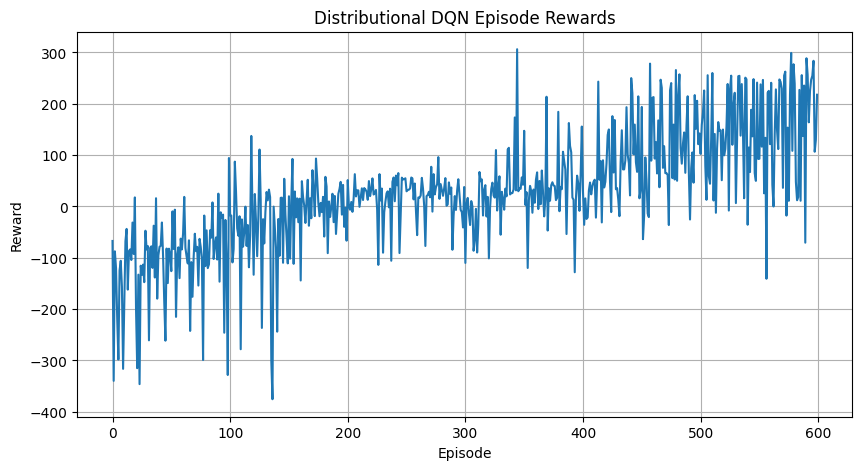

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [9]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("Distributional DQN Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("dist-dqn")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")

### 9. 분포 시각화 (Distribution Visualization)

에이전트가 예측한 보상의 분포를 시각화해본다. 에이전트가 현재 상태를 얼마나 좋게(또는 나쁘게) 보고 있는지, 그리고 그 확신도는 어떤지 확인할 수 있다.

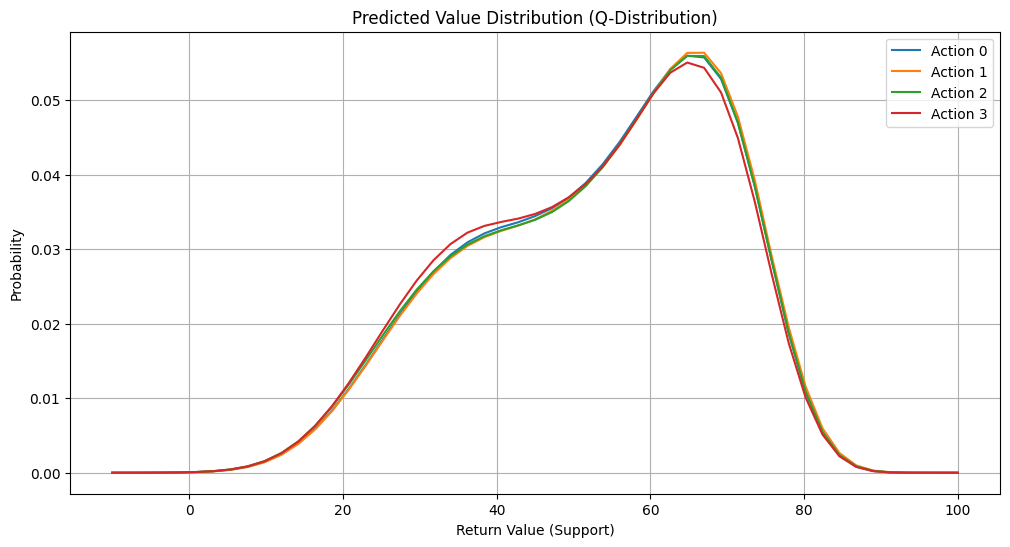

In [11]:
def plot_distribution(agent, state):
    state_t = torch.tensor(np.array([state]), device=device)
    with torch.no_grad():
        log_probs = agent.q_net(state_t)
        probs = log_probs.exp().cpu().numpy()[0] # (Actions, Atoms)

    # 행동별 분포 그리기
    plt.figure(figsize=(12, 6))
    for action in range(agent.env.action_space.n):
        plt.plot(agent.support.cpu().numpy(), probs[action], label=f"Action {action}")

    plt.title("Predicted Value Distribution (Q-Distribution)")
    plt.xlabel("Return Value (Support)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

# 학습된 에이전트로 분포 확인
temp_env = gym.make('LunarLander-v3')
state, _ = temp_env.reset()
plot_distribution(agent, state)
temp_env.close()